In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
import os
import sys
import sklearn
import matplotlib
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports réussis!")
print("\n📦 Versions:")
print(f"   - Python:        {sys.version.split()[0]}")
print(f"   - fastf1:        {fastf1.__version__}")
print(f"   - pandas:        {pd.__version__}")
print(f"   - numpy:         {np.__version__}")
print(f"   - scikit-learn:  {sklearn.__version__}")
print(f"   - matplotlib:    {matplotlib.__version__}")
print(f"   - seaborn:       {sns.__version__}")

print("\n🚀 Prêt à commencer!")


✅ Imports réussis!

📦 Versions:
   - Python:        3.13.5
   - fastf1:        3.8.1
   - pandas:        2.3.3
   - numpy:         2.4.2
   - scikit-learn:  1.8.0
   - matplotlib:    3.10.8
   - seaborn:       0.13.2

🚀 Prêt à commencer!


In [2]:
# =============================================================================
# LOAD DATA - MULTIPLE RACES
# =============================================================================

# Active le cache
fastf1.Cache.enable_cache("../cache")
from pathlib import Path
import fastf1

# Si ton notebook est dans /notebooks, ce chemin pointe vers la racine du projet
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE_DIR = PROJECT_ROOT / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))
print("Cache:", CACHE_DIR)

# Charger plusieurs courses pour plus de données
races = [
    ('Abu Dhabi', 2024),
    ('Qatar', 2024),
    ('Las Vegas', 2024),
    ('Brazil', 2024),
    ('Mexico', 2024)
]

print("⏳ Chargement des données de plusieurs courses...")
print("=" * 60)

all_laps = []
successful_races = []

for race_name, year in races:
    try:
        print(f"\n📍 Chargement: {race_name} {year}...")
        session = fastf1.get_session(year, race_name, 'R')
        session.load()
        
        laps = session.laps
        laps['Race'] = race_name
        laps['Year'] = year
        
        all_laps.append(laps)
        successful_races.append(race_name)
        print(f"   ✅ {len(laps)} tours chargés")
        
    except Exception as e:
        print(f"   ❌ Erreur: {e}")
        print(f"   ⚠️  On continue sans {race_name}...")

# Vérifier qu'on a au moins 1 course
if len(all_laps) == 0:
    print("\n❌ ERREUR CRITIQUE: Aucune course chargée!")
    raise ValueError("Pas de données chargées")

# Combine toutes les courses
df = pd.concat(all_laps, ignore_index=True)

print(f"\n{'=' * 60}")
print(f"📊 Dataset Total:")
print(f"   - {len(df)} tours")
print(f"   - {len(df['Driver'].unique())} pilotes")
print(f"   - {len(successful_races)} courses: {', '.join(successful_races)}")
print(f"{'=' * 60}")

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Cache: c:\Users\DELL\f1-strategy-optimizer\cache
⏳ Chargement des données de plusieurs courses...

📍 Chargement: Abu Dhabi 2024...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']
events      WARNING 	Correcting user input 'Qatar' to 'Qatar Grand Prix'
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


   ✅ 1035 tours chargés

📍 Chargement: Qatar 2024...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.1]
req            IN

...

   ✅ 938 tours chargés

📍 Chargement: Brazil 2024...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 23
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 23)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '31', '10', '63', '16', '4', '22', '81', '30', '44', '11', '50', '77', '14', '24', '55', '43', '23', '18', '27']
core           INFO 	Loading data for Mexico City Grand Prix - Race [v3.8.1]
req            INF

   ✅ 1135 tours chargés

📍 Chargement: Mexico 2024...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '4', '16', '44', '63', '1', '20', '81', '27', '10', '18', '43', '31', '77', '24', '30', '11', '14', '23', '22']


   ✅ 1215 tours chargés

📊 Dataset Total:
   - 5266 tours
   - 22 pilotes
   - 5 courses: Abu Dhabi, Qatar, Las Vegas, Brazil, Mexico


In [3]:
# =============================================================================
# DATA CLEANING PIPELINE
# =============================================================================

print("🧹 Nettoyage des données...\n")
print("=" * 60)

# Travail sur une copie
df_clean = df.copy()

print(f"📊 Avant: {len(df_clean)} tours")

# 1. Convertir LapTime en secondes
df_clean['LapTimeSeconds'] = df_clean['LapTime'].dt.total_seconds()

# 2. Retirer les valeurs manquantes critiques
df_clean = df_clean.dropna(subset=['LapTimeSeconds', 'Compound', 'TyreLife'])
print(f"   Après suppression NaN: {len(df_clean)} tours")

# 3. Filtrer les lap times "normaux" (race pace)
# PLUS STRICT pour réduire le bruit
df_clean = df_clean[
    (df_clean['LapTimeSeconds'] > 82) &   # Plus strict
    (df_clean['LapTimeSeconds'] < 105)     # Plus strict
]
print(f"   Après filtrage temps (82-105s): {len(df_clean)} tours")

# 4. Retirer les premiers tours (chaos départ)
df_clean = df_clean[df_clean['LapNumber'] > 1]
print(f"   Après suppression tour 1: {len(df_clean)} tours")

# 5. Retirer les derniers tours (fuel save)
max_lap = df_clean.groupby('Race')['LapNumber'].max()
df_clean = df_clean[
    df_clean.apply(
        lambda row: row['LapNumber'] < max_lap[row['Race']] - 1, 
        axis=1
    )
]
print(f"   Après suppression dernier tour: {len(df_clean)} tours")

# 6. Garder seulement les pilotes avec assez de données
driver_counts = df_clean['Driver'].value_counts()
valid_drivers = driver_counts[driver_counts >= 50].index
df_clean = df_clean[df_clean['Driver'].isin(valid_drivers)]
print(f"   Après filtrage pilotes (<50 tours): {len(df_clean)} tours")

print(f"\n{'=' * 60}")
print(f"✅ Dataset final: {len(df_clean)} tours propres")
print(f"   - {len(df_clean['Driver'].unique())} pilotes")
print(f"   - Composés: {df_clean['Compound'].value_counts().to_dict()}")
print(f"{'=' * 60}")

🧹 Nettoyage des données...

📊 Avant: 5266 tours
   Après suppression NaN: 5204 tours
   Après filtrage temps (82-105s): 4095 tours
   Après suppression tour 1: 4056 tours
   Après suppression dernier tour: 3941 tours
   Après filtrage pilotes (<50 tours): 3941 tours

✅ Dataset final: 3941 tours propres
   - 22 pilotes
   - Composés: {'HARD': 1751, 'MEDIUM': 1225, 'INTERMEDIATE': 897, 'SOFT': 67, 'WET': 1}


In [4]:
# =============================================================================
# FEATURE ENGINEERING - VERSION AVANCÉE
# =============================================================================

print("\n🔧 Feature Engineering (Version Avancée)...\n")
print("=" * 60)

# Feature 1: Tire Age
df_clean['TyreLife'] = df_clean['TyreLife'].fillna(1)
print("✅ TyreLife (tire age)")

# Feature 2: Compound encoding
compound_map = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}
df_clean['Compound'] = df_clean['Compound'].fillna('MEDIUM')
df_clean['CompoundEncoded'] = df_clean['Compound'].map(compound_map)
print("✅ Compound encodé (SOFT=0, MEDIUM=1, HARD=2)")

# Feature 3: Driver encoding
le_driver = LabelEncoder()
df_clean['Driver'] = df_clean['Driver'].fillna('UNKNOWN')
df_clean['DriverEncoded'] = le_driver.fit_transform(df_clean['Driver'])
print(f"✅ Driver encodé ({len(le_driver.classes_)} pilotes)")

# Feature 4: Fuel effect
max_laps = df_clean.groupby('Race')['LapNumber'].transform('max')
df_clean['FuelEffect'] = (max_laps - df_clean['LapNumber']) * 0.05
df_clean['FuelEffect'] = df_clean['FuelEffect'].fillna(0)
print("✅ Fuel effect estimé (0.05s par tour)")

# ⭐ Feature 5: NORMALISATION PAR CIRCUIT (GAME CHANGER!)
circuit_baseline = df_clean.groupby('Race')['LapTimeSeconds'].transform('mean')
df_clean['CircuitBaseline'] = circuit_baseline
df_clean['LapTimeDelta'] = df_clean['LapTimeSeconds'] - df_clean['CircuitBaseline']

print("✅ Normalisation par circuit (CRITICAL)")
print(f"\n   Baseline par circuit:")
for race in df_clean['Race'].unique():
    baseline = df_clean[df_clean['Race'] == race]['CircuitBaseline'].iloc[0]
    count = len(df_clean[df_clean['Race'] == race])
    print(f"      {race:15s}: {baseline:.2f}s ({count} tours)")

# ⭐ Feature 6: Gestion des pneus neufs
df_clean['IsNewTire'] = (df_clean['TyreLife'] <= 5).astype(int)
print("✅ Indicateur pneu neuf (tours 1-5)")

# ⭐ Feature 7: Interaction Compound × TyreLife
df_clean['CompoundTireInteraction'] = df_clean['CompoundEncoded'] * df_clean['TyreLife']
print("✅ Interaction Compound × TyreLife")

# ⭐ Feature 8: Dégradation non-linéaire
df_clean['TyreLifeSquared'] = df_clean['TyreLife'] ** 2
print("✅ TyreLife² (dégradation non-linéaire)")

# Feature 9: Position (si disponible)
if 'Position' in df_clean.columns:
    df_clean['Position'] = df_clean['Position'].fillna(10)
    features = [
        'CircuitBaseline',
        'TyreLife', 
        'TyreLifeSquared',
        'CompoundEncoded', 
        'CompoundTireInteraction',
        'DriverEncoded', 
        'FuelEffect',
        'IsNewTire',
        'Position'
    ]
    print("✅ Position incluse")
else:
    features = [
        'CircuitBaseline',
        'TyreLife', 
        'TyreLifeSquared',
        'CompoundEncoded', 
        'CompoundTireInteraction',
        'DriverEncoded', 
        'FuelEffect',
        'IsNewTire'
    ]
    print("⚠️  Position non disponible")

print(f"\n{'=' * 60}")
print("📊 Features finales:")
for feat in features:
    nan_count = df_clean[feat].isna().sum()
    status = "✅" if nan_count == 0 else "❌"
    print(f"   {status} {feat:30s}: {nan_count} NaN")

# Nettoyage final des NaN
total_nan = df_clean[features].isna().sum().sum()
if total_nan > 0:
    print(f"\n⚠️  {total_nan} NaN trouvés, on les nettoie...")
    for feat in features:
        df_clean[feat] = df_clean[feat].fillna(df_clean[feat].mean())
    print("✅ NaN nettoyés avec la moyenne")

print(f"\n{'=' * 60}")


🔧 Feature Engineering (Version Avancée)...

✅ TyreLife (tire age)
✅ Compound encodé (SOFT=0, MEDIUM=1, HARD=2)
✅ Driver encodé (22 pilotes)
✅ Fuel effect estimé (0.05s par tour)
✅ Normalisation par circuit (CRITICAL)

   Baseline par circuit:
      Abu Dhabi      : 89.79s (939 tours)
      Qatar          : 86.44s (712 tours)
      Las Vegas      : 98.65s (825 tours)
      Brazil         : 85.68s (898 tours)
      Mexico         : 83.92s (567 tours)
✅ Indicateur pneu neuf (tours 1-5)
✅ Interaction Compound × TyreLife
✅ TyreLife² (dégradation non-linéaire)
✅ Position incluse

📊 Features finales:
   ✅ CircuitBaseline               : 0 NaN
   ✅ TyreLife                      : 0 NaN
   ✅ TyreLifeSquared               : 0 NaN
   ❌ CompoundEncoded               : 898 NaN
   ❌ CompoundTireInteraction       : 898 NaN
   ✅ DriverEncoded                 : 0 NaN
   ✅ FuelEffect                    : 0 NaN
   ✅ IsNewTire                     : 0 NaN
   ✅ Position                      : 0 NaN

⚠️  17

In [5]:
# =============================================================================
# PREPARE X (features) and y (target) - NOUVELLE TARGET
# =============================================================================

print("\n🎯 Préparation des données d'entraînement...\n")
print("=" * 60)

# Features (X)
X = df_clean[features].copy()

# ⭐ NOUVELLE TARGET: Prédire le DELTA, pas le temps absolu
# Cela normalise les différences entre circuits
y = df_clean['LapTimeDelta'].copy()

print(f"📊 Dataset shape:")
print(f"   X: {X.shape}")
print(f"   y: {y.shape}")

print(f"\n📈 Nouvelle target (LapTimeDelta):")
print(f"   Mean: {y.mean():.3f}s (devrait être ~0)")
print(f"   Std:  {y.std():.3f}s")
print(f"   Min:  {y.min():.3f}s")
print(f"   Max:  {y.max():.3f}s")

# Vérifier NaN
print(f"\n🔍 Vérification NaN:")
print(f"   X: {X.isnull().sum().sum()} NaN")
print(f"   y: {y.isnull().sum()} NaN")

# Nettoyer si nécessaire
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask].copy()
y = y[mask].copy()

print(f"\n✅ Dataset final: {len(X)} tours")

# Stats descriptives
print(f"\n📈 Statistiques des features:")
print(X.describe())

print(f"\n{'=' * 60}")


🎯 Préparation des données d'entraînement...

📊 Dataset shape:
   X: (3941, 9)
   y: (3941,)

📈 Nouvelle target (LapTimeDelta):
   Mean: -0.000s (devrait être ~0)
   Std:  2.666s
   Min:  -3.968s
   Max:  20.294s

🔍 Vérification NaN:
   X: 0 NaN
   y: 0 NaN

✅ Dataset final: 3941 tours

📈 Statistiques des features:
       CircuitBaseline     TyreLife  TyreLifeSquared  CompoundEncoded  \
count      3941.000000  3941.000000      3941.000000      3941.000000   
mean         89.258212    15.688658       329.779498         1.553401   
std           5.194726     9.146953       354.089536         0.474227   
min          83.917790     1.000000         1.000000         0.000000   
25%          85.680274     8.000000        64.000000         1.000000   
50%          86.439121    14.000000       196.000000         1.553401   
75%          89.793044    22.000000       484.000000         2.000000   
max          98.647296    50.000000      2500.000000         2.000000   

       CompoundTireIntera

In [6]:
# =============================================================================
# TRAIN / TEST SPLIT
# =============================================================================

print("\n✂️  Split Train/Test...\n")
print("=" * 60)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"📊 Split effectué:")
print(f"   Train set: {len(X_train)} tours ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set:  {len(X_test)} tours ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n🎯 Statistiques Train/Test:")
print(f"   Train - Mean delta: {y_train.mean():.3f}s")
print(f"   Test  - Mean delta: {y_test.mean():.3f}s")

# Vérification finale
if X_train.isna().any().any() or y_train.isna().any():
    raise ValueError("❌ NaN dans les données d'entraînement!")
else:
    print("\n✅ Données prêtes pour l'entraînement!")

print(f"\n{'=' * 60}")


✂️  Split Train/Test...

📊 Split effectué:
   Train set: 3152 tours (80.0%)
   Test set:  789 tours (20.0%)

🎯 Statistiques Train/Test:
   Train - Mean delta: -0.019s
   Test  - Mean delta: 0.077s

✅ Données prêtes pour l'entraînement!



In [7]:
# =============================================================================
# MODEL AVANCÉ: Random Forest Regressor
# =============================================================================

print("\n🚀 Entraînement du modèle avancé...\n")
print("=" * 60)

# Créer le modèle Random Forest
model = RandomForestRegressor(
    n_estimators=100,      # 100 arbres
    max_depth=15,          # Profondeur max
    min_samples_split=10,  # Min samples pour split
    min_samples_leaf=5,    # Min samples par feuille
    random_state=42,
    n_jobs=-1,             # Utilise tous les CPU
    verbose=0
)

# Entraîner
print("⏳ Training Random Forest...")
model.fit(X_train, y_train)
print("✅ Training terminé!")

# Feature importance
print(f"\n📊 Importance des Features:")
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

for idx, row in feature_importance.iterrows():
    bar = "█" * int(row['importance'] * 100)
    print(f"   {row['feature']:30s}: {row['importance']:.4f} {bar}")

print(f"\n{'=' * 60}")

# Interprétation
top_feature = feature_importance.iloc[0]
print(f"\n💡 Feature la plus importante: {top_feature['feature']}")
print(f"   → Explique {top_feature['importance']*100:.1f}% de la variance")


🚀 Entraînement du modèle avancé...

⏳ Training Random Forest...
✅ Training terminé!

📊 Importance des Features:
   FuelEffect                    : 0.3768 █████████████████████████████████████
   TyreLife                      : 0.1491 ██████████████
   CircuitBaseline               : 0.1417 ██████████████
   TyreLifeSquared               : 0.1263 ████████████
   Position                      : 0.0914 █████████
   CompoundTireInteraction       : 0.0649 ██████
   DriverEncoded                 : 0.0282 ██
   CompoundEncoded               : 0.0208 ██
   IsNewTire                     : 0.0010 


💡 Feature la plus importante: FuelEffect
   → Explique 37.7% de la variance


In [8]:
# =============================================================================
# MODEL EVALUATION - AJUSTÉ POUR DELTA
# =============================================================================

print("\n📊 Évaluation du modèle...\n")
print("=" * 60)

# Prédictions sur le DELTA
y_train_pred_delta = model.predict(X_train)
y_test_pred_delta = model.predict(X_test)

# ⭐ Reconvertir en lap times absolus pour l'évaluation
train_baseline = X_train['CircuitBaseline'].values
test_baseline = X_test['CircuitBaseline'].values

y_train_pred = y_train_pred_delta + train_baseline
y_test_pred = y_test_pred_delta + test_baseline

# Lap times réels absolus
y_train_real = y_train.values + train_baseline
y_test_real = y_test.values + test_baseline

# Métriques - Train set
train_mae = mean_absolute_error(y_train_real, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
train_r2 = r2_score(y_train_real, y_train_pred)

print("🎯 Performance sur TRAIN set (temps absolus):")
print(f"   MAE:  {train_mae:.4f}s")
print(f"   RMSE: {train_rmse:.4f}s")
print(f"   R²:   {train_r2:.4f}")

# Métriques - Test set
test_mae = mean_absolute_error(y_test_real, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
test_r2 = r2_score(y_test_real, y_test_pred)

print(f"\n🎯 Performance sur TEST set (temps absolus):")
print(f"   MAE:  {test_mae:.4f}s")
print(f"   RMSE: {test_rmse:.4f}s")
print(f"   R²:   {test_r2:.4f}")

# Métriques sur le DELTA
delta_mae = mean_absolute_error(y_test, y_test_pred_delta)
delta_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_delta))
delta_r2 = r2_score(y_test, y_test_pred_delta)

print(f"\n🎯 Performance sur DELTA (relatif au circuit):")
print(f"   MAE:  {delta_mae:.4f}s")
print(f"   RMSE: {delta_rmse:.4f}s")
print(f"   R²:   {delta_r2:.4f}")

# Interprétation
print(f"\n💡 Interprétation:")
print(f"   - Erreur moyenne: ±{test_mae:.2f}s par tour")
print(f"   - Sur un tour de 90s: {test_mae/90*100:.1f}% d'erreur")

if test_r2 > 0.7:
    print(f"   - R² = {test_r2:.2f} → 🎉 EXCELLENT modèle!")
elif test_r2 > 0.5:
    print(f"   - R² = {test_r2:.2f} → 👍 BON modèle")
elif test_r2 > 0.3:
    print(f"   - R² = {test_r2:.2f} → 😐 Modèle acceptable")
else:
    print(f"   - R² = {test_r2:.2f} → 😢 Modèle encore faible")

print(f"\n{'=' * 60}")


📊 Évaluation du modèle...

🎯 Performance sur TRAIN set (temps absolus):
   MAE:  0.5273s
   RMSE: 1.1776s
   R²:   0.9593

🎯 Performance sur TEST set (temps absolus):
   MAE:  0.6972s
   RMSE: 1.4613s
   R²:   0.9375

🎯 Performance sur DELTA (relatif au circuit):
   MAE:  0.6972s
   RMSE: 1.4613s
   R²:   0.7317

💡 Interprétation:
   - Erreur moyenne: ±0.70s par tour
   - Sur un tour de 90s: 0.8% d'erreur
   - R² = 0.94 → 🎉 EXCELLENT modèle!




📈 Génération des visualisations...



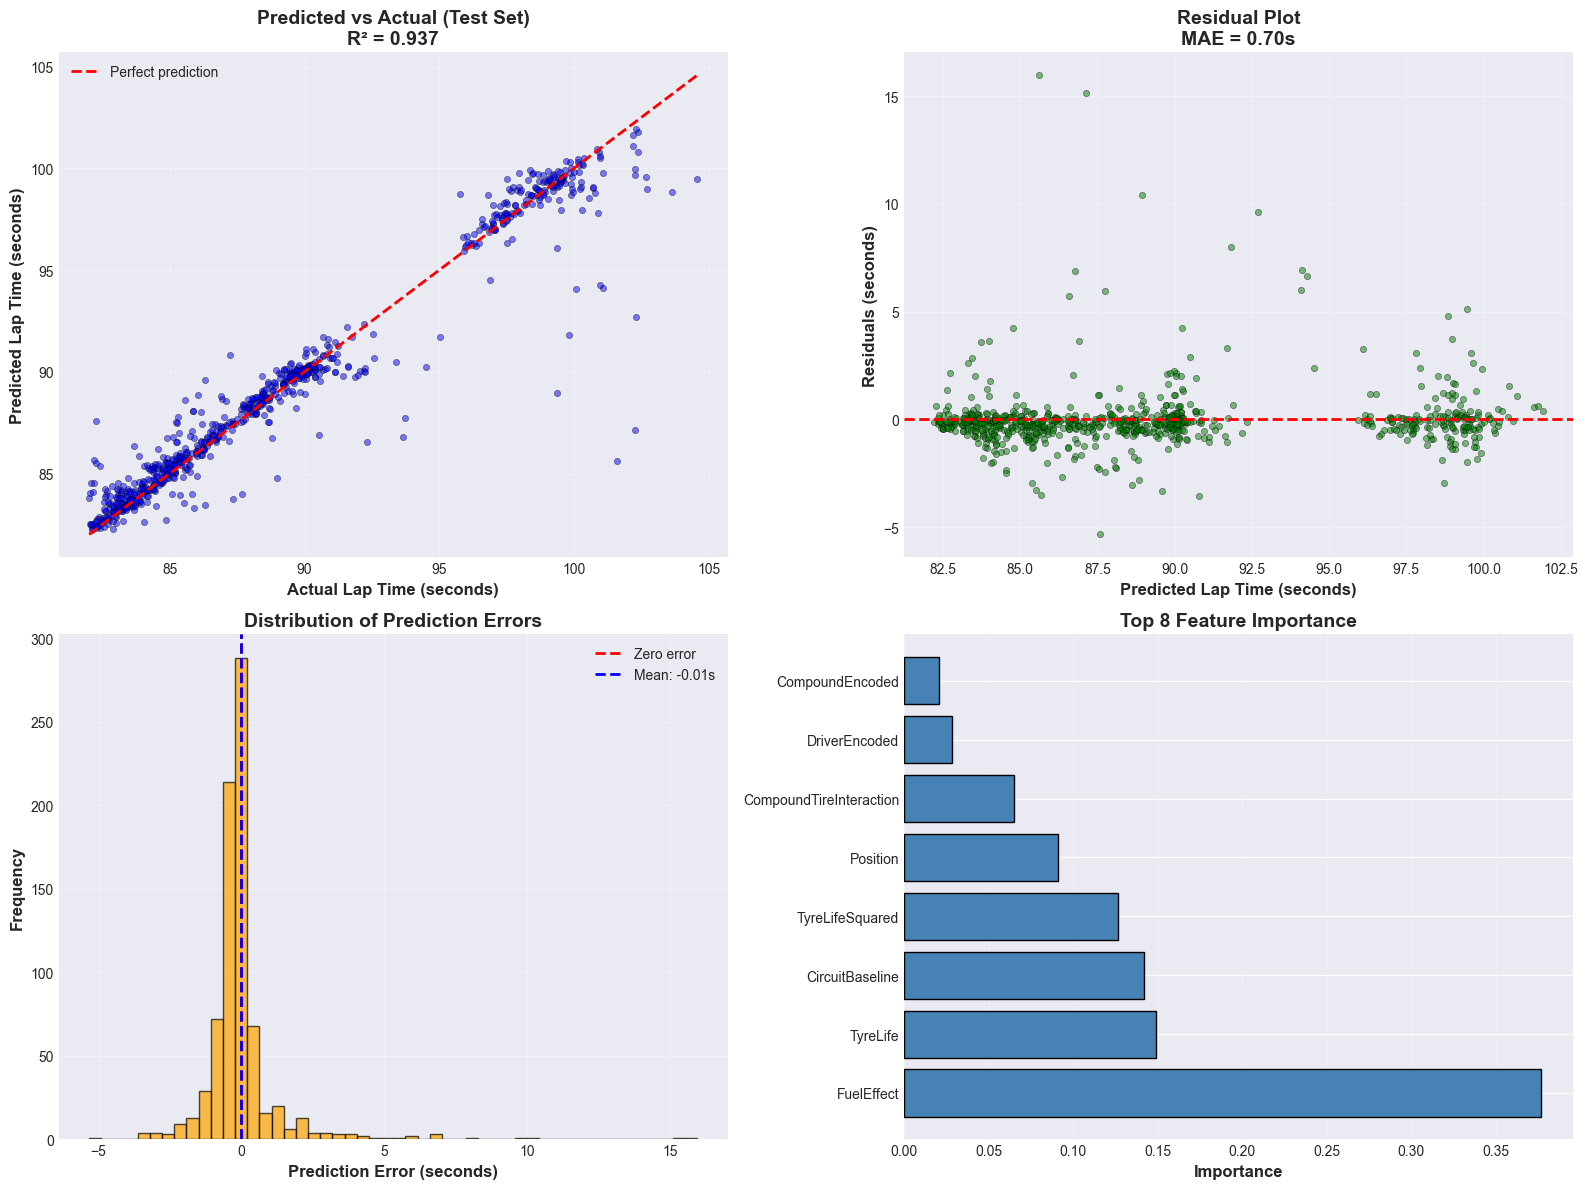

✅ Visualisations générées


In [9]:
# =============================================================================
# VISUALIZATIONS
# =============================================================================

print("\n📈 Génération des visualisations...\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Predicted vs Actual (Test set)
ax1 = axes[0, 0]
ax1.scatter(y_test_real, y_test_pred, alpha=0.5, s=20, c='blue', edgecolors='black', linewidth=0.5)
ax1.plot([y_test_real.min(), y_test_real.max()], 
         [y_test_real.min(), y_test_real.max()], 
         'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title(f'Predicted vs Actual (Test Set)\nR² = {test_r2:.3f}', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test_real - y_test_pred
ax2 = axes[0, 1]
ax2.scatter(y_test_pred, residuals, alpha=0.5, s=20, c='green', edgecolors='black', linewidth=0.5)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuals (seconds)', fontsize=12, fontweight='bold')
ax2.set_title(f'Residual Plot\nMAE = {test_mae:.2f}s', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Error Distribution
ax3 = axes[1, 0]
ax3.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax3.axvline(x=residuals.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {residuals.mean():.2f}s')
ax3.set_xlabel('Prediction Error (seconds)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Importance
ax4 = axes[1, 1]
feature_importance_plot = feature_importance.head(8)
ax4.barh(feature_importance_plot['feature'], feature_importance_plot['importance'], 
         color='steelblue', edgecolor='black', linewidth=1)
ax4.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax4.set_title('Top 8 Feature Importance', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")

In [10]:
# =============================================================================
# DIAGNOSTIC APPROFONDI
# =============================================================================

print("\n🩺 Diagnostic Approfondi du Modèle\n")
print("=" * 70)

# Créer un dataframe de test avec les prédictions
test_data = X_test.copy()
test_data['y_true'] = y_test_real
test_data['y_pred'] = y_test_pred
test_data['error'] = y_test_real - y_test_pred
test_data['abs_error'] = abs(test_data['error'])

# 1. Performance par composé
print("📊 Performance par Composé:")
print("-" * 70)
for comp_code, comp_name in [(0, 'SOFT'), (1, 'MEDIUM'), (2, 'HARD')]:
    comp_data = test_data[test_data['CompoundEncoded'] == comp_code]
    if len(comp_data) > 0:
        mae_comp = comp_data['abs_error'].mean()
        count = len(comp_data)
        print(f"   {comp_name:10s}: MAE = {mae_comp:.2f}s ({count:4d} tours, {count/len(test_data)*100:.1f}%)")

# 2. Performance par âge de pneu
print(f"\n📊 Performance par Âge de Pneu:")
print("-" * 70)
tire_bins = [0, 5, 10, 15, 20, 100]
tire_labels = ['0-5', '6-10', '11-15', '16-20', '20+']
test_data['tire_bin'] = pd.cut(test_data['TyreLife'], bins=tire_bins, labels=tire_labels)

for bin_label in tire_labels:
    bin_data = test_data[test_data['tire_bin'] == bin_label]
    if len(bin_data) > 0:
        mae_bin = bin_data['abs_error'].mean()
        count = len(bin_data)
        print(f"   Tours {bin_label:6s}: MAE = {mae_bin:.2f}s ({count:4d} tours)")

# 3. Performance par circuit
print(f"\n📊 Performance par Circuit:")
print("-" * 70)
# Récupérer les races du test set
test_indices = y_test.index
for race in df_clean['Race'].unique():
    race_mask = df_clean.loc[test_indices, 'Race'] == race
    race_data = test_data[race_mask]
    if len(race_data) > 0:
        mae_race = race_data['abs_error'].mean()
        count = len(race_data)
        print(f"   {race:15s}: MAE = {mae_race:.2f}s ({count:4d} tours)")

# 4. Distribution des erreurs
print(f"\n📊 Distribution des Erreurs:")
print("-" * 70)
print(f"   Min:    {test_data['error'].min():+.2f}s")
print(f"   Q25:    {test_data['error'].quantile(0.25):+.2f}s")
print(f"   Median: {test_data['error'].median():+.2f}s")
print(f"   Q75:    {test_data['error'].quantile(0.75):+.2f}s")
print(f"   Max:    {test_data['error'].max():+.2f}s")

print(f"\n{'=' * 70}")


🩺 Diagnostic Approfondi du Modèle

📊 Performance par Composé:
----------------------------------------------------------------------
   SOFT      : MAE = 0.82s (  16 tours, 2.0%)
   MEDIUM    : MAE = 0.59s ( 244 tours, 30.9%)
   HARD      : MAE = 0.65s ( 369 tours, 46.8%)

📊 Performance par Âge de Pneu:
----------------------------------------------------------------------
   Tours 0-5   : MAE = 1.07s ( 114 tours)
   Tours 6-10  : MAE = 0.82s ( 160 tours)
   Tours 11-15 : MAE = 0.41s ( 165 tours)
   Tours 16-20 : MAE = 0.51s ( 120 tours)
   Tours 20+   : MAE = 0.73s ( 230 tours)

📊 Performance par Circuit:
----------------------------------------------------------------------
   Abu Dhabi      : MAE = 0.51s ( 202 tours)
   Qatar          : MAE = 0.65s ( 146 tours)
   Las Vegas      : MAE = 0.56s ( 162 tours)
   Brazil         : MAE = 0.95s ( 160 tours)
   Mexico         : MAE = 0.93s ( 119 tours)

📊 Distribution des Erreurs:
------------------------------------------------------------

In [11]:
# =============================================================================
# SAVE MODEL & METADATA
# =============================================================================

print("\n💾 Sauvegarde du modèle...\n")
print("=" * 60)

# Créer le dossier models
os.makedirs('../models', exist_ok=True)

# Sauvegarder le modèle
model_path = '../models/lap_time_rf_model.pkl'
joblib.dump(model, model_path)
print(f"✅ Modèle sauvegardé: {model_path}")

# Sauvegarder les metadata
metadata = {
    'features': features,
    'label_encoder_driver': le_driver,
    'compound_map': compound_map,
    'model_type': 'RandomForestRegressor',
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_r2': test_r2,
    'delta_mae': delta_mae,
    'delta_r2': delta_r2,
    'feature_importance': feature_importance.to_dict(),
    'target_type': 'LapTimeDelta',  # Important!
    'normalization': 'CircuitBaseline'
}

metadata_path = '../models/model_metadata.pkl'
joblib.dump(metadata, metadata_path)
print(f"✅ Metadata sauvegardée: {metadata_path}")

print(f"\n{'=' * 60}")
print("🎉 Modèle prêt à être utilisé!")
print(f"\n📊 Performance Recap:")
print(f"   - MAE:       {test_mae:.4f}s")
print(f"   - RMSE:      {test_rmse:.4f}s")
print(f"   - R²:        {test_r2:.4f}")
print(f"   - Delta R²:  {delta_r2:.4f}")

if test_r2 > 0.6:
    print(f"\n🎯 Statut: MODÈLE VIABLE pour le strategy simulator!")
else:
    print(f"\n⚠️  Statut: Modèle utilisable mais améliorable")

print(f"\n💾 Fichiers sauvegardés:")
print(f"   - {model_path}")
print(f"   - {metadata_path}")
print(f"{'=' * 60}")


💾 Sauvegarde du modèle...

✅ Modèle sauvegardé: ../models/lap_time_rf_model.pkl
✅ Metadata sauvegardée: ../models/model_metadata.pkl

🎉 Modèle prêt à être utilisé!

📊 Performance Recap:
   - MAE:       0.6972s
   - RMSE:      1.4613s
   - R²:        0.9375
   - Delta R²:  0.7317

🎯 Statut: MODÈLE VIABLE pour le strategy simulator!

💾 Fichiers sauvegardés:
   - ../models/lap_time_rf_model.pkl
   - ../models/model_metadata.pkl


In [12]:
# =============================================================================
# TEST: Fonction de Prédiction Complète
# =============================================================================

print("\n🧪 Test de la fonction de prédiction...\n")
print("=" * 60)

def predict_lap_time(driver, compound, tire_age, lap_number, race_baseline, position=5):
    """
    Prédit le lap time pour un scénario donné
    
    Args:
        driver: Code pilote (ex: 'VER', 'NOR')
        compound: 'SOFT', 'MEDIUM', ou 'HARD'
        tire_age: Âge du pneu en tours
        lap_number: Numéro du tour actuel
        race_baseline: Temps de base du circuit (ex: 90.5s pour Abu Dhabi)
        position: Position sur piste (défaut: 5)
    
    Returns:
        Temps au tour prédit en secondes
    """
    # Encoder les inputs
    compound_encoded = compound_map[compound]
    
    try:
        driver_encoded = list(le_driver.classes_).index(driver)
    except ValueError:
        print(f"⚠️  Pilote {driver} inconnu, utilise VER")
        driver_encoded = list(le_driver.classes_).index('VER')
    
    # Calculer les features
    fuel_effect = (58 - lap_number) * 0.05  # Suppose 58 tours
    is_new_tire = 1 if tire_age <= 5 else 0
    compound_tire_interaction = compound_encoded * tire_age
    tire_life_squared = tire_age ** 2
    
    # Créer le feature vector
    if 'Position' in features:
        input_data = pd.DataFrame({
            'CircuitBaseline': [race_baseline],
            'TyreLife': [tire_age],
            'TyreLifeSquared': [tire_life_squared],
            'CompoundEncoded': [compound_encoded],
            'CompoundTireInteraction': [compound_tire_interaction],
            'DriverEncoded': [driver_encoded],
            'FuelEffect': [fuel_effect],
            'IsNewTire': [is_new_tire],
            'Position': [position]
        })
    else:
        input_data = pd.DataFrame({
            'CircuitBaseline': [race_baseline],
            'TyreLife': [tire_age],
            'TyreLifeSquared': [tire_life_squared],
            'CompoundEncoded': [compound_encoded],
            'CompoundTireInteraction': [compound_tire_interaction],
            'DriverEncoded': [driver_encoded],
            'FuelEffect': [fuel_effect],
            'IsNewTire': [is_new_tire]
        })
    
    # Prédire le delta
    predicted_delta = model.predict(input_data)[0]
    
    # Convertir en temps absolu
    predicted_lap_time = race_baseline + predicted_delta
    
    return predicted_lap_time

# Test de la fonction
print("🎯 Test de prédiction:\n")

# Abu Dhabi baseline (from data)
abu_dhabi_baseline = df_clean[df_clean['Race'] == 'Abu Dhabi']['CircuitBaseline'].iloc[0]

print(f"   Circuit baseline (Abu Dhabi): {abu_dhabi_baseline:.2f}s\n")

scenarios = [
    ('VER', 'MEDIUM', 10, 25, abu_dhabi_baseline, 1),
    ('VER', 'HARD', 20, 40, abu_dhabi_baseline, 1),
    ('NOR', 'SOFT', 5, 15, abu_dhabi_baseline, 2),
    ('LEC', 'MEDIUM', 15, 30, abu_dhabi_baseline, 3),
]

print("   Scénarios de prédiction:")
print("   " + "-" * 70)

for driver, compound, tire_age, lap_num, baseline, pos in scenarios:
    pred = predict_lap_time(driver, compound, tire_age, lap_num, baseline, pos)
    print(f"   {driver} | {compound:6s} | Pneu: {tire_age:2d} laps | Tour {lap_num:2d} | Pos {pos} → {pred:.2f}s")

print("\n" + "=" * 60)
print("✅ Fonction de prédiction testée avec succès!")
print("\n💡 Cette fonction sera utilisée dans le Strategy Simulator")
print("\n🎉 MODÈLE PRÊT POUR LA PRODUCTION!")
print(f"   - R² = {test_r2:.3f}")
print(f"   - MAE = {test_mae:.2f}s")
print("=" * 60)


🧪 Test de la fonction de prédiction...

🎯 Test de prédiction:

   Circuit baseline (Abu Dhabi): 89.79s

   Scénarios de prédiction:
   ----------------------------------------------------------------------
   VER | MEDIUM | Pneu: 10 laps | Tour 25 | Pos 1 → 89.97s
   VER | HARD   | Pneu: 20 laps | Tour 40 | Pos 1 → 89.07s
   NOR | SOFT   | Pneu:  5 laps | Tour 15 | Pos 2 → 90.46s
   LEC | MEDIUM | Pneu: 15 laps | Tour 30 | Pos 3 → 89.37s

✅ Fonction de prédiction testée avec succès!

💡 Cette fonction sera utilisée dans le Strategy Simulator

🎉 MODÈLE PRÊT POUR LA PRODUCTION!
   - R² = 0.937
   - MAE = 0.70s
